In [1]:
import re
with open("nalgae.txt", "r", encoding="utf-8") as f:
    text = f.read().replace(" ", "_")
text = re.sub(r'[^0-9가-힣.,!?_\-()(···)"\'\n]', ' ', text)
len(text)

21457

In [2]:
len(text)/len(set(text))

26.82125

In [3]:
bag_of_word = list(set(text))
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["안"]]

'안'

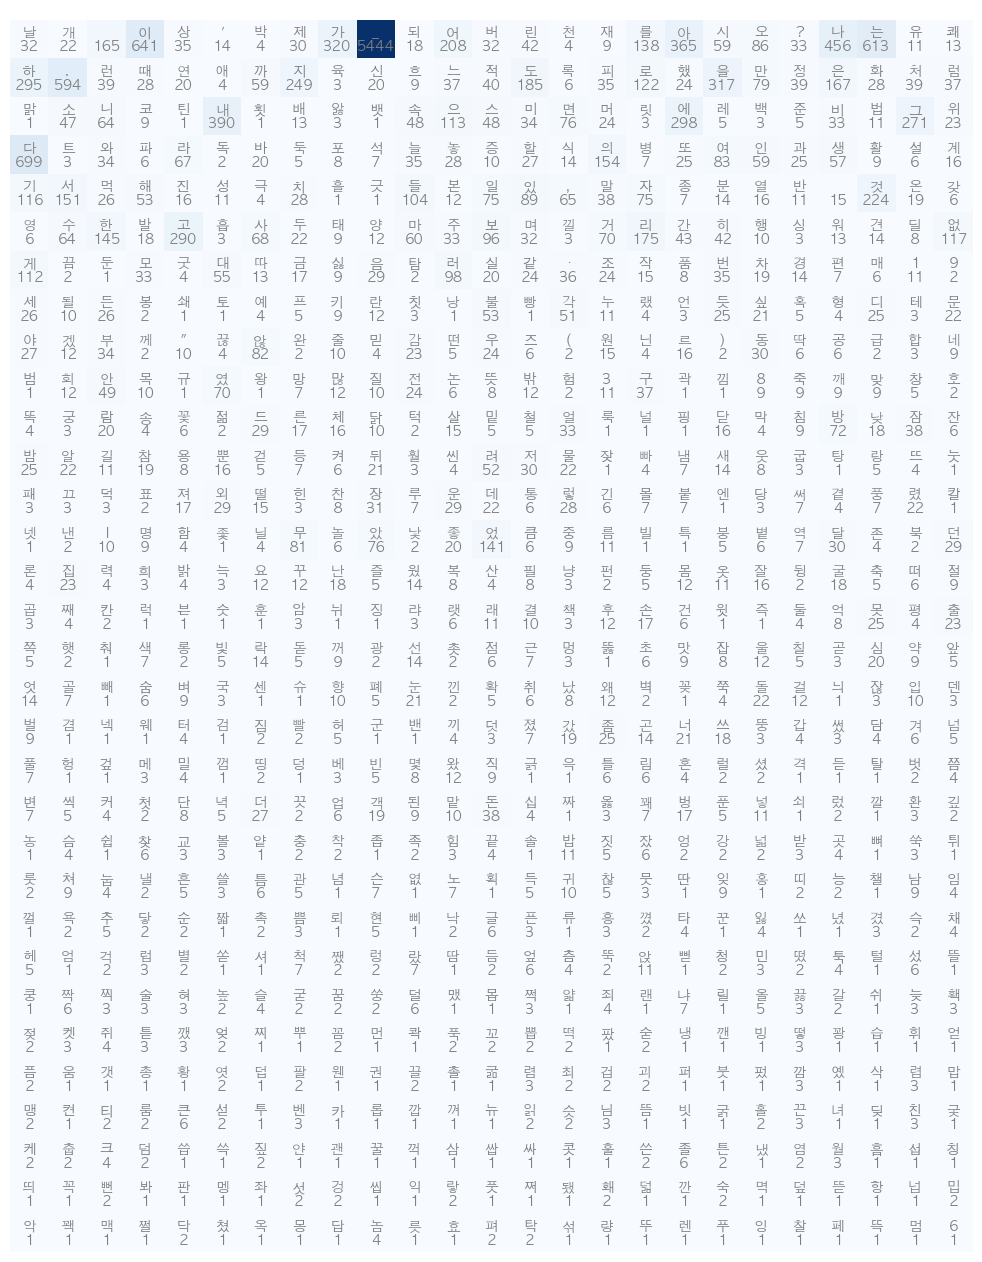

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import findfont, FontProperties
# print(findfont(FontProperties(family=['AppleGothic'])))
counter = Counter(text)
keys = list(counter.keys())

img = np.array(list(counter.values())).reshape(32, 25)
plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(img, cmap="Blues")
plt.axis("off")
for i in range(32):
    for j in range(25):
        chstr = keys[i*25+j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, str(counter[chstr]), ha="center", va="top", color="gray")

In [13]:
def make_chunks(data, n=5):
    for ptr in range(0, len(data)-n-1):
        yield data[ptr:ptr+n+1]

n = 6
chunks = [chunk for chunk in make_chunks(text, n)]

In [14]:
chunks[10:13]

['제가_되어_버', '가_되어_버린', '_되어_버린_']

In [15]:
len(chunks)

21450

In [16]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [12, 193, 553, 553, 384, 661, 553]
String: 날개

이상



In [17]:
import math
print("Total tokens:", len(stoi))
print("Current Entropy:", math.log2(len(stoi)))

Total tokens: 800
Current Entropy: 9.643856189774725


In [18]:
import random

def beautiful_f(x):
    return random.randint(0, total_tokens)

def generate(x, function, max_length=100, **kwrgs):
    for i in range(len(x), max_length):
        x += stringfy([function(x[i-n:i], **kwrgs)])
    return x

chunk = chunks[0]
x = chunk[:n]
y = chunk[n]
print(generate(x, beautiful_f))

날개

이상렀끼배꺼것!긋배쯤동키확켓듯먹등섣범저잖새듣떴낼몰인궁막픔끝띄숫껄팠렴딪해받찬쁨괴홱석롱은냐홀맙대질철활깔쑥렇횟쁨밴윽왕북슴괜떡빈깊쪽혼꾼쪽횟래넣노노녔외에대낌띵론당렀취았꽂최람덴슨쳤린터


# 오차 역전파에 대해서 알아보자.

In [19]:
import torch
w1_torch = torch.randn(3, 2, requires_grad=True)
b1_torch = torch.randn(3, requires_grad=True)
x_torch = torch.randn(2, requires_grad=True)
y = w1_torch @ x_torch + b1_torch
loss = y.sum()
loss.backward()
print("w1:",w1_torch.grad)
print("b1:",b1_torch.grad)
print("x:",x_torch.grad)

w1: tensor([[0.5104, 1.7958],
        [0.5104, 1.7958],
        [0.5104, 1.7958]])
b1: tensor([1., 1., 1.])
x: tensor([-1.4473,  0.8249])


In [20]:
import numpy as np

x = x_torch.detach().numpy()
W1 = w1_torch.detach().numpy()
B1 = b1_torch.detach().numpy()
y = W1 @ x + B1

In [21]:
dydW1 = np.stack([x, x, x], axis=0)
dydB1 = np.ones(3)
dydX = np.sum(W1, axis=0)
print("w1:",dydW1)
print("b1:",dydB1)
print("x:",dydX)

w1: [[0.51044416 1.7957633 ]
 [0.51044416 1.7957633 ]
 [0.51044416 1.7957633 ]]
b1: [1. 1. 1.]
x: [-1.4472504  0.8249355]


In [22]:
import numpy as np

W = np.random.randn(1, n) / 100
B = np.zeros((1))

losses = []
for _ in range(100):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n] / total_tokens
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(chunk)

    y = W @ x + B
    error = np.sum((y-ground_truth) ** 2)
    print("Square Error:", error)
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = 2*(y-ground_truth)
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-2
    W -= lr * dEdW
    B -= lr * dEdB


_들어가지_않
Square Error: 0.29227992995528346
_이제는_더_
Square Error: 0.10484546608951197
_꿈이_얼쑹덜
Square Error: 0.0008801620154955948
소._니코틴이
Square Error: 0.2027678290267287
_설계하오._
Square Error: 0.0744419827684378
이_방이_가운
Square Error: 0.09560752102840614
터면_나는_까
Square Error: 0.000517824483948249
않다.
한_번
Square Error: 0.003939080469154386
_건너가_버렸
Square Error: 0.008691618124886894
것을_먹고_한
Square Error: 0.014109503721172856
구멍을_뚫어_
Square Error: 0.060400511908827614
다._나는_내
Square Error: 0.13188271430790383
슷하게_아물아
Square Error: 0.241697491253709
인간_세상의_
Square Error: 0.029247555076956436
내면서_드디어
Square Error: 0.021043042801704832
을지도_모른다
Square Error: 0.006495848169169359
_이런_피로를
Square Error: 0.17438169097603498
것은_바로_그
Square Error: 0.0073501588651546474
는다._해가_
Square Error: 0.04229596779115764
나다!_그야말
Square Error: 0.0026765781877533235
_수_없게_되
Square Error: 0.39200800340696
꼼짝할_힘조차
Square Error: 0.22878074005006135
느꼈다.
아내
Square Error: 0.042362106750261724
_나갔는지_알
Square Error: 0.05

Text(0.5, 0, 'epoch')

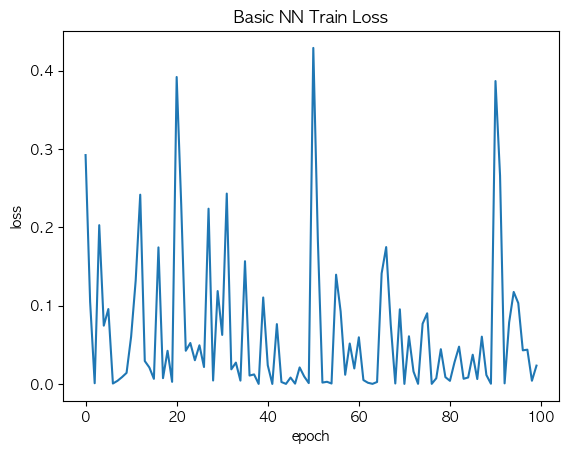

In [23]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic NN Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [24]:
def simple_linear(x, **kwrgs):
    x = np.array(tokenize(x)) / total_tokens
    y = kwrgs["W"] @ x + kwrgs["B"]
    return np.clip(np.ceil(y*total_tokens), 0, total_tokens-1)[-1]

generate("날개는 돋았", simple_linear, W=W, B=B)

'날개는 돋았랗숨출습었습얻뿌얻얻익충충랐랐랐랐랐랐슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬슬'

In [25]:
it = list(set(generate("날개는 돋았", simple_linear, W=W, B=B)))
for char in it:
    print(stoi[char] / total_tokens) # 0.5를 출력하는 멍청이..

0.33
0.33125
0.3325
0.3425
0.33375
0.24125
0.335
0.015
0.31125
0.3375
0.33875
0.3525
0.3275
0.09125
0.4325
0.605
0.32875


Text(0.5, 1.0, 'weight distribution')

/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


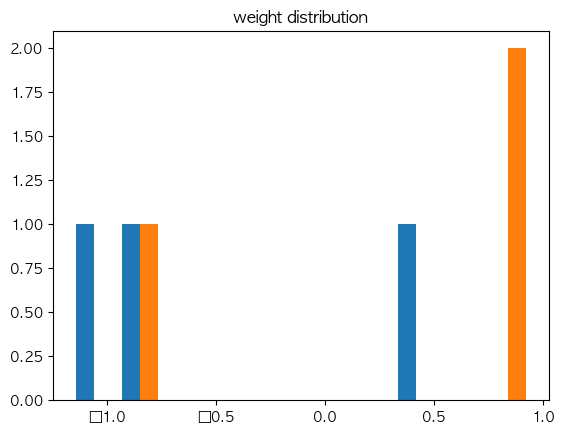

In [26]:
plt.hist(W1)
plt.title("weight distribution")

In [27]:
W = np.random.randn(total_tokens, n) / 100
B = np.zeros((total_tokens))

losses = []
for _ in range(1000):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n]
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(f"{chunk[:n]} -> {chunk[n]}")

    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    # print(softmaxed)
    error = -np.log2(softmaxed[ground_truth])
    print("Entropy Error:", error, "Prediction:", itos[np.argmax(softmaxed)])
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = softmaxed
    dEdy[ground_truth] -= 1
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-2
    W -= lr * dEdW
    B -= lr * dEdB

_돌아오기_ -> 전
Entropy Error: 9.640046271610107 Prediction: 오
이_아내에게 -> _
Entropy Error: 9.674388852179087 Prediction: 오
의_얼굴을_ -> 쳐
Entropy Error: 9.642665201219684 Prediction: 오
었다._이것 -> 을
Entropy Error: 9.63377072251006 Prediction: 오
는_이미_외 -> 출
Entropy Error: 9.642617763392861 Prediction: 오
_호흡을_하 -> 여
Entropy Error: 9.630864203210118 Prediction: 돈
을_누가_알 -> 랴
Entropy Error: 9.676179700512048 Prediction: 끔
인지도_모른 -> 다
Entropy Error: 9.61676613781808 Prediction: 오
드름처럼_돋 -> 았
Entropy Error: 9.658997547812014 Prediction: 끔
이국적인_센 -> 슈
Entropy Error: 9.625357731184431 Prediction: 론
의_커피가_ -> 즐
Entropy Error: 9.636945882100893 Prediction: 끔
_틈으로_흐 -> 르
Entropy Error: 9.655849240609053 Prediction: 오
오지_않았나 -> _
Entropy Error: 9.651260529743102 Prediction: 끔
.
그것은_ -> 그
Entropy Error: 9.640038203655152 Prediction: 론
참_이상하다 -> 는
Entropy Error: 9.682094559544787 Prediction: 오
_"너_밤새 -> _
Entropy Error: 9.605850577515314 Prediction: 오
_타_주었다 -> .
Entropy Error: 9.59512467067721 Prediction: 돈


Text(0.5, 0, 'epoch')

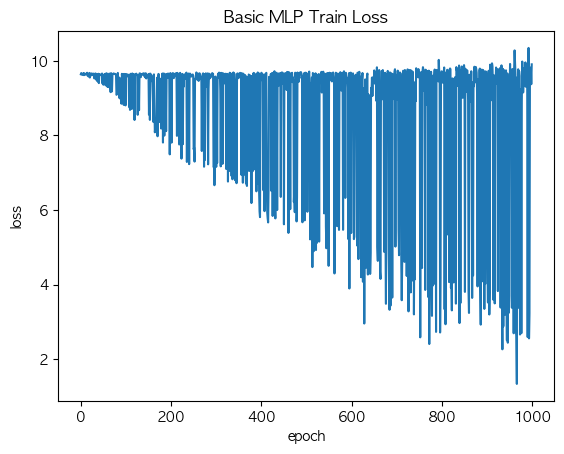

In [28]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic MLP Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [29]:
def logistic(x, W, B):
    x = np.array(tokenize(x)) / total_tokens
    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    return np.random.choice(len(softmaxed), p=softmaxed)

generate("날개는_돋았", logistic, W=W, B=B).replace(" ", "_")

'날개는_돋았독덴_켠귀아며_마돌위낮숟섭옜_합\n이뱃뻔죽츰케재갈끌___푼척_관만왕번림폐장몽른넥굳족존늬픈8져쳤경___위짝외_밖켓왜고햇운엔허몹냐글틀목저6_혼레온늦랜음굵겼양뉴험몰객넓섣쨌념웬최'

In [30]:
emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
print(Emb[:2])
Emb[[1, 0, 1]]

[[-1.00860065  0.08512408 -1.38922764  1.03681528  0.59221874  0.04979658
  -0.56861348  1.06611959  1.53478953 -0.10540979]
 [-0.43437016 -0.98173653  0.02304247  1.21264989  1.21260582 -1.21618981
  -1.94132208 -0.96828393  0.00755775 -1.23074823]]


array([[-0.43437016, -0.98173653,  0.02304247,  1.21264989,  1.21260582,
        -1.21618981, -1.94132208, -0.96828393,  0.00755775, -1.23074823],
       [-1.00860065,  0.08512408, -1.38922764,  1.03681528,  0.59221874,
         0.04979658, -0.56861348,  1.06611959,  1.53478953, -0.10540979],
       [-0.43437016, -0.98173653,  0.02304247,  1.21264989,  1.21260582,
        -1.21618981, -1.94132208, -0.96828393,  0.00755775, -1.23074823]])

In [43]:
import tqdm

emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
W = np.random.randn(total_tokens, n*emb_size) / 100
B = np.zeros((total_tokens))

losses = []
small_batch = 32
# epoch
for epoch in tqdm.trange(10000):
    # parameter
    parameters = {
        "dEdW": np.zeros_like(W),
        "dEdB": np.zeros_like(B),
        "dEdEmb": np.zeros_like(Emb),
    }
    epoch_loss = 0.0
    # batch
    for i in range(small_batch):
        chunk = random.choice(chunks)
        ground_truth = tokenize(chunk)[n]
        indexs = tokenize(chunk)[:n]
        x = Emb[indexs].reshape(-1)

        y = W @ x + B
        exped = np.exp(y-y.max())
        softmaxed = exped / np.sum(exped, keepdims=False)
        loss = -np.log2(softmaxed[ground_truth])
        epoch_loss += loss

        dEdy = softmaxed
        dEdy[ground_truth] -= 1
        dEdW = dEdy[:, None] * x[None, :]
        dEdB = dEdy.copy()
        dEdX = W.T @ dEdy
        dEdEmb = np.zeros_like(Emb)
        dEdEmb[indexs] += dEdX.reshape(n, emb_size)
        parameters["dEdW"] += dEdW
        parameters["dEdB"] += dEdB
        parameters["dEdEmb"] += dEdEmb

    avg_loss = epoch_loss / small_batch
    if epoch % 50 == 0:
        pred = np.argmax(y)
        print(f"{chunk[:n]} -> {chunk[n]}")
        print("Entropy Error (avg):", avg_loss, "Prediction:", itos[pred])
        losses.append(avg_loss)

    # optimizer
    lr = 5e-3
    W -= lr * parameters["dEdW"] / small_batch
    B -= lr * parameters["dEdB"] / small_batch
    Emb -= lr * parameters["dEdEmb"] / small_batch

  0%|          | 3/10000 [00:00<06:16, 26.58it/s]

던_향기_가 -> 운
Entropy Error (avg): 9.683948275116956 Prediction: 탐


  1%|          | 55/10000 [00:03<08:07, 20.41it/s]

중_세_시나 -> _
Entropy Error (avg): 9.330428578582454 Prediction: _


  1%|          | 102/10000 [00:05<08:19, 19.83it/s]

...

 99%|█████████▉| 9904/10000 [09:00<00:04, 21.13it/s]

아온_것이다 -> .
Entropy Error (avg): 5.73050687248157 Prediction: .


100%|█████████▉| 9954/10000 [09:02<00:02, 21.29it/s]

었다._아파 -> _
Entropy Error (avg): 5.885481429899437 Prediction: _


100%|██████████| 10000/10000 [09:04<00:00, 18.35it/s]


In [45]:
np.savez_compressed(f"simp{n}.npz", W=W, B=B, Emb=Emb)
data = np.load(f"simp{n}.npz")
W = data["W"]
B = data["B"]
Emb = data["Emb"]

Text(0.5, 0, 'epoch')

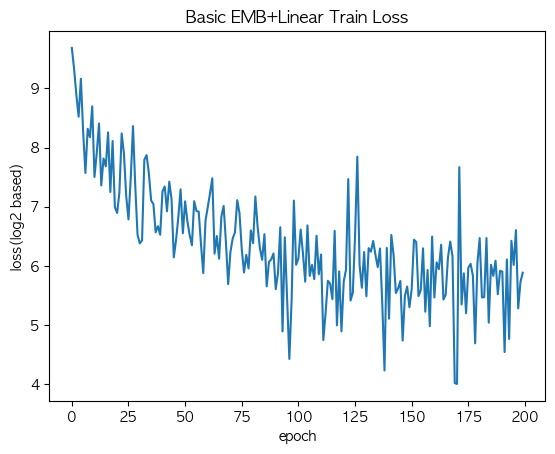

In [46]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic EMB+Linear Train Loss")
plt.ylabel("loss(log2 based)")
plt.xlabel("epoch")

In [47]:
def logistic(x):
    indexs = tokenize(x.replace(" ", "_"))
    x = Emb[indexs].reshape(-1)
    y = W @ x + B
    exped = np.exp((y-y.max()) / 0.5)
    softmaxed = exped / np.sum(exped, keepdims=False)
    return np.random.choice(len(softmaxed), p=softmaxed)
generate("박제가_되어버린_", logistic, max_length=50)

'박제가_되어버린_아내_내_이_가_이_서_없_나_이_가_하_가_다_다._나는_이_이_이_하고'

In [42]:
generate("___슬픈_", logistic, max_length=50)

'___슬픈_____________________________________________'

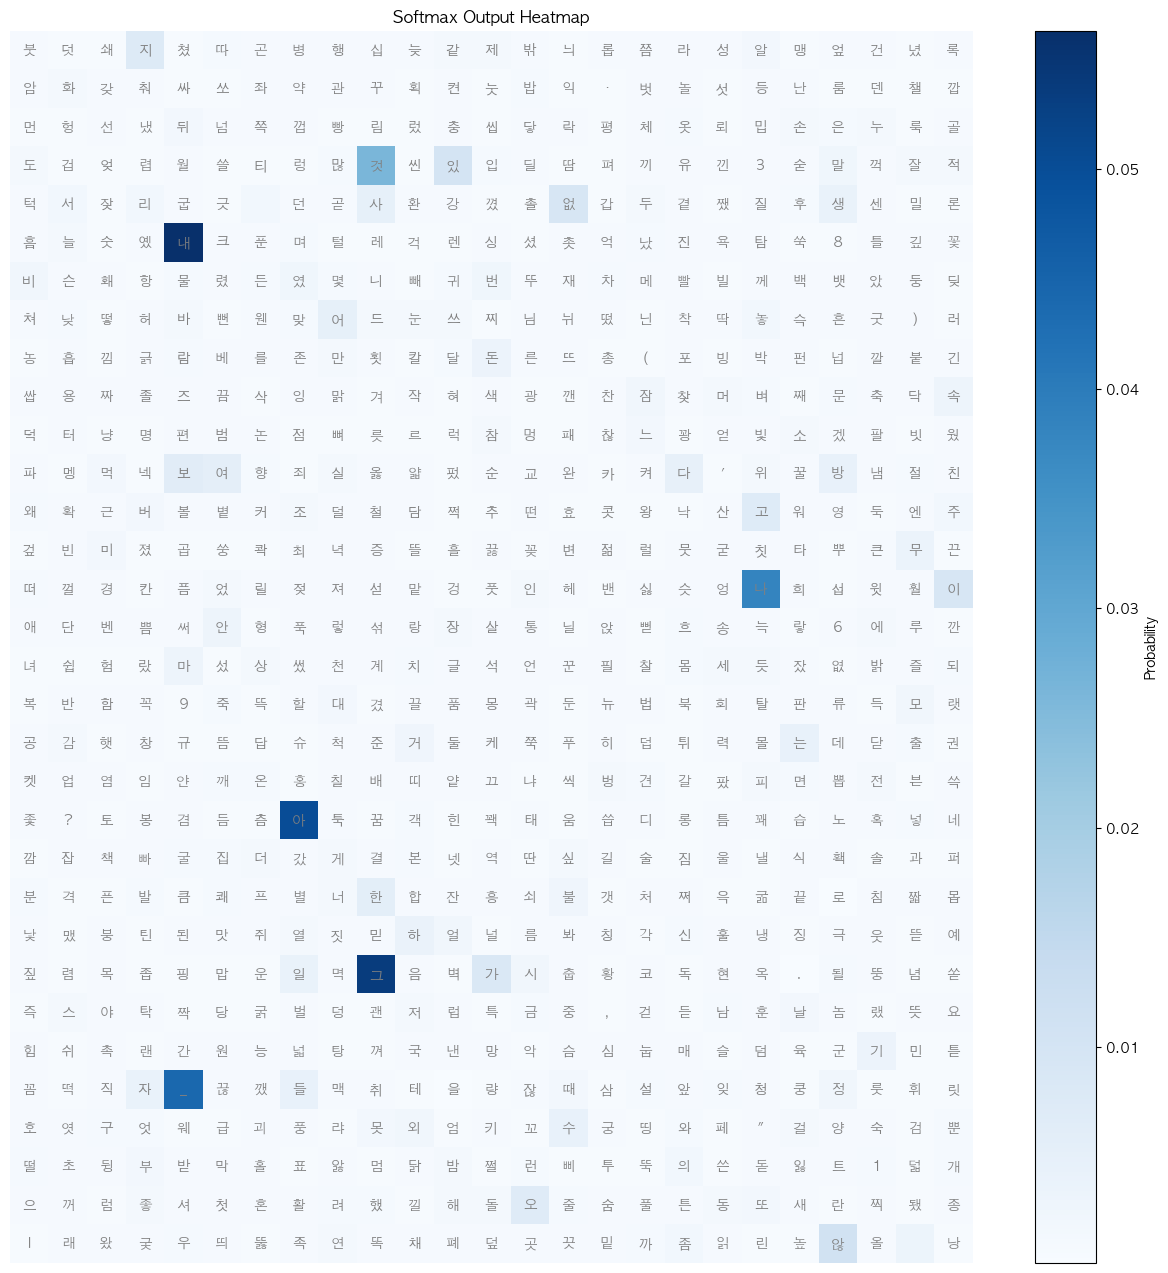

In [ ]:
indexs = tokenize("감정_")
x = Emb[indexs].reshape(-1)
y = W @ x + B
exped = np.exp(y-y.max())
softmaxed = exped / np.sum(exped, keepdims=False)

plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(softmaxed.reshape(32, 25), cmap="Blues")
plt.colorbar(label="Probability")  # add this line
plt.title("Softmax Output Heatmap")
plt.axis("off")
for i in range(32):
    for j in range(25):
        chstr = itos[i*25+j]
        plt.text(j, i, chstr, ha="center", va="center", color="gray")
        # plt.text(j, i, f"{softmaxed[i*25+j]:.2f}", ha="center", va="top", color="gray")